# Buildbot Analysis for LLM Paper: Engagement Data (T7)
This notebook analyzes the qualitative assessments of children's interactions with the LLM (Marty) at timepoint T7.
Variables analyzed:
1. LLM_enjoyment: How did you like your last voice interaction with Marty? (1-5)
2. LLM_learning: How much did your last conversation with Marty help you learn? (1-5)
3. LLM_contributions: Did you feel everyone talked to Marty equally? (1-4)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['font.size'] = 12

In [2]:
# Load data with ISO-8859-1 encoding
data_path = Path('Data/Qualtrics/BuildBots_engagement_children_T1-T7.csv')
df = pd.read_csv(data_path, encoding='ISO-8859-1')

# Filter for T7 (Post-session LLM interaction)
df_t7 = df[df['Timepoint'] == 'T7'].copy()

print(f"Total responses at T7: {len(df_t7)}")
df_t7[['LLM_enjoyment', 'LLM_learning', 'LLM_contributions']].describe()

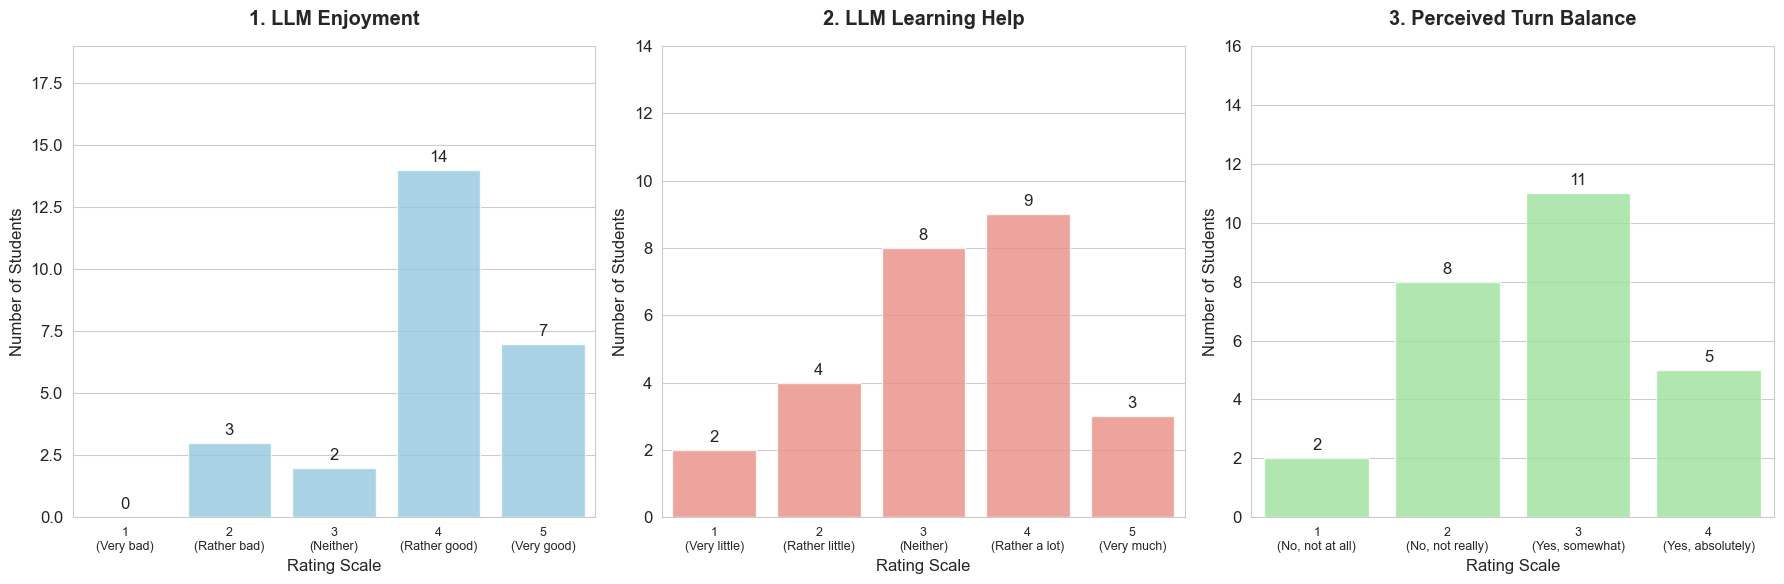

In [3]:
# Define qualitative labels for our 3 metrics
enjoyment_labels = {1: 'Very bad', 2: 'Rather bad', 3: 'Neither', 4: 'Rather good', 5: 'Very good'}
learning_labels = {1: 'Very little', 2: 'Rather little', 3: 'Neither', 4: 'Rather a lot', 5: 'Very much'}
contribution_labels = {1: 'No, not at all', 2: 'No, not really', 3: 'Yes, somewhat', 4: 'Yes, absolutely'}

def plot_distribution(data, column, title, labels_map, color, subplot_idx):
    plt.subplot(1, 3, subplot_idx)
    
    # Ensure all scale points (1-5 or 1-4) are shown, even if they have 0 counts
    possible_values = sorted(labels_map.keys())
    counts = data[column].value_counts().reindex(possible_values).fillna(0)
    
    # Create the bar plot
    ax = sns.barplot(x=counts.index, y=counts.values, color=color, alpha=0.8)
    
    plt.title(title, fontweight='bold', pad=15)
    plt.xlabel('Rating Scale')
    plt.ylabel('Number of Students')
    plt.ylim(0, counts.max() + 5) # Add space for labels
    
    # Add count labels on top of each bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')
    
    # Replace numeric ticks with our qualitative labels
    plt.xticks(ticks=range(len(possible_values)), 
               labels=[f"{v}\n({labels_map[v]})" for v in possible_values], 
               fontsize=9)

# Create the 3-panel figure
plt.figure(figsize=(18, 6))

plot_distribution(df_t7, 'LLM_enjoyment', '1. LLM Enjoyment', enjoyment_labels, 'skyblue', 1)
plot_distribution(df_t7, 'LLM_learning', '2. LLM Learning Help', learning_labels, 'salmon', 2)
plot_distribution(df_t7, 'LLM_contributions', '3. Perceived Turn Balance', contribution_labels, 'lightgreen', 3)

plt.tight_layout()
plt.savefig('llm_interaction_distributions_t7.png', dpi=300, bbox_inches='tight')
plt.show()

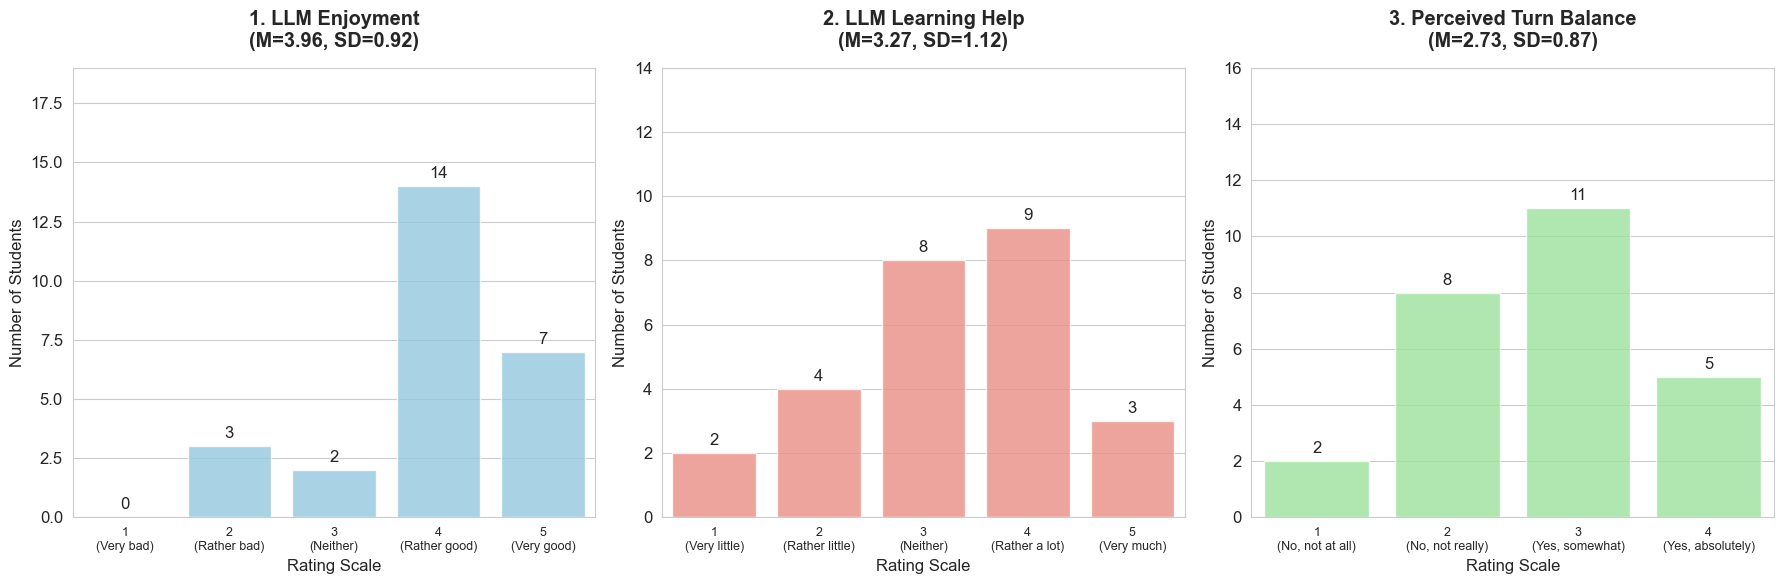

In [4]:
# 1. Define qualitative labels for our 3 metrics
enjoyment_labels = {1: 'Very bad', 2: 'Rather bad', 3: 'Neither', 4: 'Rather good', 5: 'Very good'}
learning_labels = {1: 'Very little', 2: 'Rather little', 3: 'Neither', 4: 'Rather a lot', 5: 'Very much'}
contribution_labels = {1: 'No, not at all', 2: 'No, not really', 3: 'Yes, somewhat', 4: 'Yes, absolutely'}

def plot_distribution(data, column, title, labels_map, color, subplot_idx):
    plt.subplot(1, 3, subplot_idx)
    
    # Calculate Mean and Standard Deviation
    col_mean = data[column].mean()
    col_std = data[column].std()
    
    # Ensure all scale points (1-5 or 1-4) are shown, even if they have 0 counts
    possible_values = sorted(labels_map.keys())
    counts = data[column].value_counts().reindex(possible_values).fillna(0)
    
    # Create the bar plot
    ax = sns.barplot(x=counts.index, y=counts.values, color=color, alpha=0.8)
    
    # Update title to include Mean and SD
    plt.title(f"{title}\n(M={col_mean:.2f}, SD={col_std:.2f})", fontweight='bold', pad=15)
    plt.xlabel('Rating Scale')
    plt.ylabel('Number of Students')
    plt.ylim(0, counts.max() + 5) # Add space for labels
    
    # Add count labels on top of each bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')
    
    # Replace numeric ticks with our qualitative labels
    plt.xticks(ticks=range(len(possible_values)), 
               labels=[f"{v}\n({labels_map[v]})" for v in possible_values], 
               fontsize=9)

# Create the 3-panel figure
plt.figure(figsize=(18, 6))

plot_distribution(df_t7, 'LLM_enjoyment', '1. LLM Enjoyment', enjoyment_labels, 'skyblue', 1)
plot_distribution(df_t7, 'LLM_learning', '2. LLM Learning Help', learning_labels, 'salmon', 2)
plot_distribution(df_t7, 'LLM_contributions', '3. Perceived Turn Balance', contribution_labels, 'lightgreen', 3)

plt.tight_layout()
plt.savefig('llm_interaction_distributions_t7_with_stats.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary of Findings (T7)

The analysis of the 26 student responses at timepoint T7 reveals the following average ratings:

- **Mean Enjoyment**: `3.96` (Close to "Rather good")
- **Mean Learning Help**: `3.27` (Above "Neither")
- **Mean Perceived Equality**: `2.73` (Between "No, not really" and "Yes, somewhat")

/var/folders/q5/pk7qj5ls4j742f50_1901z000000gq/T/ipykernel_15186/3290823171.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=turn_categories, y=turn_values, palette=colors)
/var/folders/q5/pk7qj5ls4j742f50_1901z000000gq/T/ipykernel_15186/3290823171.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=off_categories, y=off_values, palette=colors)


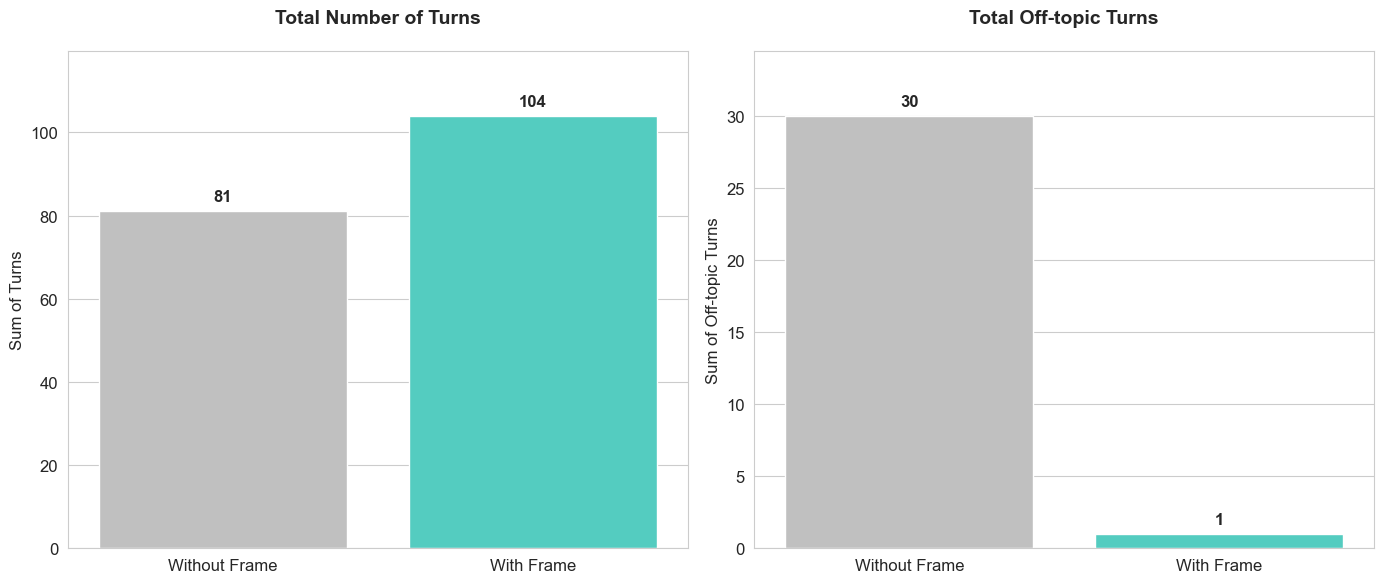

Aggregate Totals for the Study:
Total Turns: No Frame = 81 | With Frame = 104
Total Off-topic: No Frame = 30 | With Frame = 1


In [10]:
# 1. Prepare the data for total counts
comp_data = df_analysis[[
    'Number of Turns in Frame', 
    'Number of Turns in No Frame', 
    'Out of topic turns  with frame', 
    'Out of topic turns without Frame'
]].dropna()

# Calculate the Totals (Sums)
totals = {
    'Turns (With Frame)': comp_data['Number of Turns in Frame'].sum(),
    'Turns (No Frame)': comp_data['Number of Turns in No Frame'].sum(),
    'Off-topic (With Frame)': comp_data['Out of topic turns  with frame'].sum(),
    'Off-topic (No Frame)': comp_data['Out of topic turns without Frame'].sum()
}

# Define colors: Silver for No Frame, Turquoise for Frame
colors = ['silver', '#40E0D0'] # #40E0D0 is a vibrant Turquoise

# 2. Visualization
plt.figure(figsize=(14, 6))

# Subplot 1: Total Number of Turns
plt.subplot(1, 2, 1)
turn_categories = ['Without Frame', 'With Frame']
turn_values = [totals['Turns (No Frame)'], totals['Turns (With Frame)']]

ax1 = sns.barplot(x=turn_categories, y=turn_values, palette=colors)
plt.title("Total Number of Turns", fontweight='bold', fontsize=14, pad=20)
plt.ylabel("Sum of Turns", fontsize=12)
plt.ylim(0, max(turn_values) * 1.15)

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', 
                fontweight='bold', fontsize=12)

# Subplot 2: Total Number of Off-topic Turns
plt.subplot(1, 2, 2)
off_categories = ['Without Frame', 'With Frame']
off_values = [totals['Off-topic (No Frame)'], totals['Off-topic (With Frame)']]

ax2 = sns.barplot(x=off_categories, y=off_values, palette=colors)
plt.title("Total Off-topic Turns", fontweight='bold', fontsize=14, pad=20)
plt.ylabel("Sum of Off-topic Turns", fontsize=12)
plt.ylim(0, max(off_values) * 1.15)

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', 
                fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Print the numeric totals for the paper
print("Aggregate Totals for the Study:")
print(f"Total Turns: No Frame = {int(totals['Turns (No Frame)'])} | With Frame = {int(totals['Turns (With Frame)'])}")
print(f"Total Off-topic: No Frame = {int(totals['Off-topic (No Frame)'])} | With Frame = {int(totals['Off-topic (With Frame)'])}")